In [140]:
import random
import copy
import matplotlib.pyplot as plt
import numpy as np

In [141]:
def monte_carlo_integral(f, bounds, N):
    m = len(bounds)
    volume = 1.0
    for a, b in bounds:
        volume *= (b - a)

    total = 0.0
    for _ in range(N):
        point = []
        for a, b in bounds:
            point.append(random.uniform(a, b))
        total += f(*point)

    return volume * total / N

In [142]:
f = lambda x, y, z: x * y * z
bounds = [(0, 1), (0, 1), (0, 1)]
N = 50000

In [143]:
result = monte_carlo_integral(f, bounds, N)
print(f"Приближённое значение интеграла: {result}")

Приближённое значение интеграла: 0.12537209622449424


In [144]:
def monte_carlo_system(alphas, betas, N):
    if(sum(map(sum, alphas)) < 1 and all(num >= 0 for row in alphas for num in row)):
        ps = copy.deepcopy(alphas)
        vs = []
        for i in range(len(ps)):
            vs.append([])
            for j in range(len(ps[0])):
                vs[i].append(alphas[i][j] / ps[i][j])
        P = copy.deepcopy(ps)
        arr = [0] * len(ps[0])
        arr.append(1)
        P.append(arr)
        for i in range(0, len(P) - 1):
            P[i].append(1 - sum(P[i]))
    elif(sum(map(sum, alphas)) >= 1):
        alphas_copy = copy.deepcopy(alphas)
        while sum(map(sum, alphas_copy)) >= 1:
            biggest = 0
            first_idx = 0
            second_idx = 0
            for i in range(len(alphas_copy)):
                for j in range(len(alphas_copy[0])):
                    val = alphas_copy[i][j]
                    if val > biggest:
                        biggest = val
                        first_idx, second_idx = i, j

            alphas_copy[first_idx][second_idx] -= 0.1
        ps = copy.deepcopy(alphas_copy)
        vs = []
        for i in range(len(ps)):
            vs.append([])
            for j in range(len(ps[0])):
                vs[i].append(alphas_copy[i][j] / ps[i][j])
        P = copy.deepcopy(ps)
        arr = [0] * len(ps[0])
        arr.append(1)
        P.append(arr)
        for i in range(0, len(P) - 1):
            P[i].append(1 - sum(P[i]))
    else:
        raise Exception("Матрица содержит отрицательные элементы!")
    n = len(betas)
    x = [0.0] * n

    for i in range(n):
        total = 0.0
        
        for _ in range(N):
            state = i 
            weight = 1.0
            result = betas[i] 
            
            for step in range(100):
                r = random.random()
                cum_prob = 0.0
                next_state = n
                
                for j in range(n + 1):
                    cum_prob += P[state][j]
                    if r < cum_prob:
                        next_state = j
                        break
                
                if next_state == n:
                    break
                
                result += weight * betas[next_state]
                
                state = next_state
            
            total += result
        
        x[i] = total / N
    return x

In [145]:
res = monte_carlo_system([[0.2, 0.1],[0.1, 0.5]], [0.4, 0.2], 10000)
print(f"Приближённые значения х1 и х2: {res}")

Приближённые значения х1 и х2: [0.5662799999999758, 0.5144799999999647]


In [146]:
def monte_carlo_area(x, y, conditions, N=10000):
    x_min, x_max = x[0], x[1]
    y_min, y_max = y[0], y[1]
    S_rect = (x_max - x_min) * (y_max - y_min)

    K = 0

    points_inside_x = []
    points_inside_y = []
    points_outside_x = []
    points_outside_y = []

    for _ in range(N):
        current_x = random.uniform(x_min, x_max)
        current_y = random.uniform(y_min, y_max)
        
        if all(condition(current_x, current_y) for condition in conditions):
            K += 1
            points_inside_x.append(current_x)
            points_inside_y.append(current_y)
        else:
            points_outside_x.append(current_x)
            points_outside_y.append(current_y)
    
    S_approx = S_rect * K / N
    
    print(f"Количество точек: N = {N}")
    print(f"Точек внутри фигуры: K = {K}")
    print(f"Площадь прямоугольника: S_прям = {S_rect}")
    print(f"Приближённая площадь фигуры: S ≈ {S_approx:.6f}")
    
    plt.figure(figsize=(10, 8))
    plt.scatter(points_outside_x, points_outside_y, c='red', s=1, alpha=0.3, label='Вне фигуры')
    plt.scatter(points_inside_x, points_inside_y, c='blue', s=1, alpha=0.5, label='Внутри фигуры')
    
    plt.axhline(y=y_min, color='black', linewidth=1)
    plt.axhline(y=y_max, color='black', linewidth=1)
    plt.axvline(x=x_min, color='black', linewidth=1)
    plt.axvline(x=x_max, color='black', linewidth=1)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Метод Монте-Карло: N={N}, S≈{S_approx:.4f}')
    plt.legend(markerscale=3)
    plt.grid(True, alpha=0.3)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()
    
    return S_approx, K

Количество точек: N = 10000
Точек внутри фигуры: K = 4015
Площадь прямоугольника: S_прям = 16
Приближённая площадь фигуры: S ≈ 6.424000


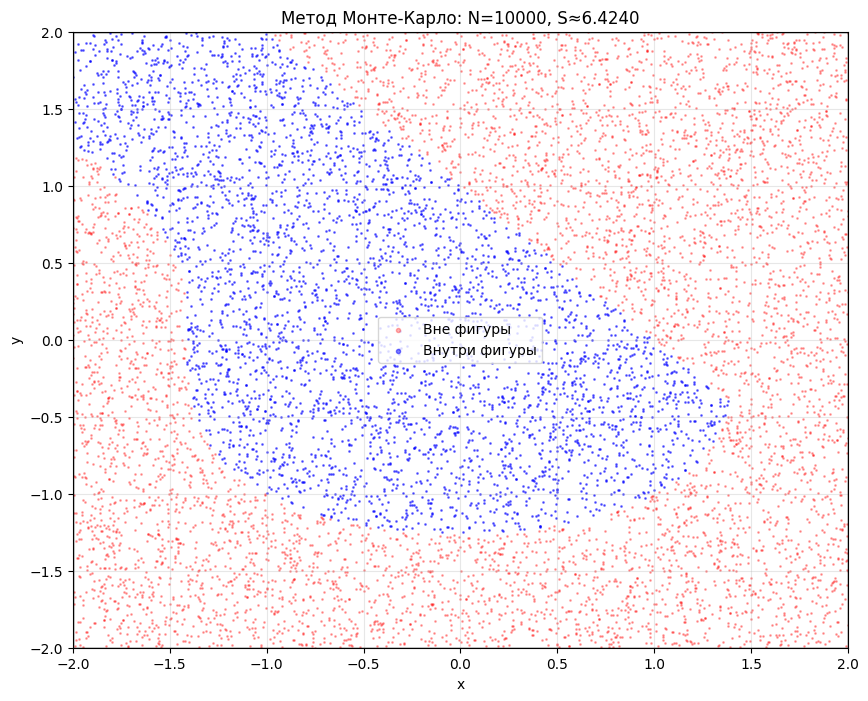

In [147]:
area, k = monte_carlo_area([-2, 2], [-2, 2], [lambda x,y: x**2-y**3 < 2,lambda x,y: x+y < 1])